In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("../notebook/credit_card_fraud_10k.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [21]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB
None


In [22]:
df.isna().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [23]:
df=df.drop_duplicates()

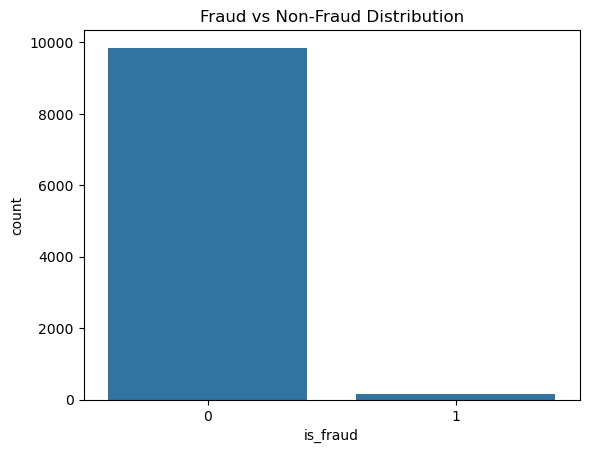

In [24]:
plt.figure()
sns.countplot(x="is_fraud", data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

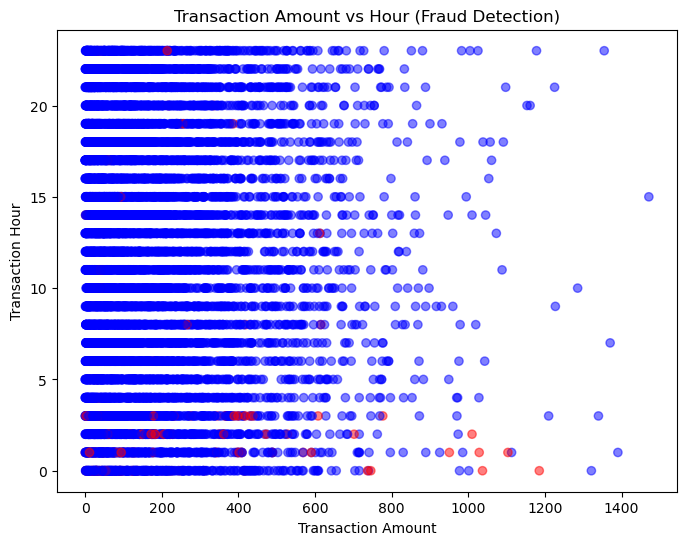

In [25]:
colors = df["is_fraud"].map({0: "blue", 1: "red"})

plt.figure(figsize=(8,6))
plt.scatter(
    df["amount"],
    df["transaction_hour"],
    c=colors,
    alpha=0.5
)

plt.xlabel("Transaction Amount")
plt.ylabel("Transaction Hour")
plt.title("Transaction Amount vs Hour (Fraud Detection)")
plt.show()

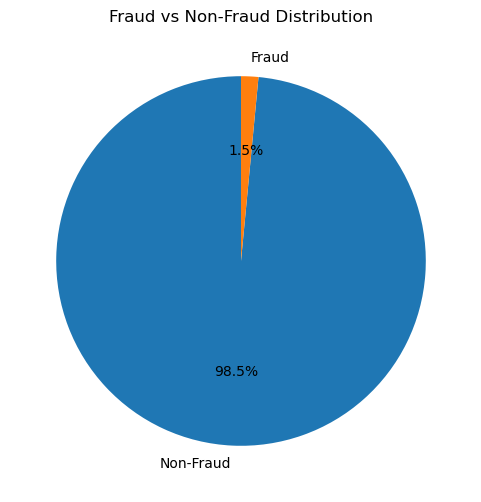

In [26]:
fraud_counts = df["is_fraud"].value_counts()


plt.figure(figsize=(6,6))
plt.pie(
    fraud_counts,
    labels=["Non-Fraud", "Fraud"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

In [27]:
df.to_csv("../notebook/cleaned_data.csv", index=False)